# Assignemnt
In this assignment, you will implement (or complete the implementation) a basic ray tracking program that displays two spheres and a plane. The shading model to be used is the Phong reflection as described in the following link (Description section):

https://en.wikipedia.org/wiki/Phong_reflection_modelLinks to an external site.

To complete the assignment, you can start with the code in the following repository:

https://github.com/eraldoribeiro/raycastingLinks to an external site.

The notebook containing the starter code is: https://github.com/eraldoribeiro/raycasting/blob/main/rayTracingBasic.ipynbLinks to an external site.

The code creates an image of two spheres. But, there is no shading and there is no plane. You will need to extend the code to create the functions for plane intersection and the Phong reflection (shading) model.

Once you complete the assignment and create the output image, you submit your assignment by adding your repository URL to Canvas.

You are expected to implement, produce results, descriptions (mathematical and textual) of the following:

1. Basic ray tracking method (recursive)

2. Reflection

3. Refraction

4. Glossy  reflection

5. Rendering the scene from multiple view points

6. Soft shadows

These can be all combined into a single scene but your program must allow for switching between some of the basic properties.





# Imports and Classes

In [28]:
import numpy as np               # Numpy library
from PIL import Image as im      # Basic image processing library
import random

In [29]:
class Ray:
    """A class representing a ray (line in space).

    Uses the parametric representation of a line, p(t) = e + (s - e)*t.

    The ray passes through the following two points:

    e = [e_u, e_v, e_w] representing the eye location in 3-D, and
    s = [e_u, e_v, e_w] representing a point on the image plane.

    Attributes:
        e: 3x1 np.array, e.g.,
        s: 3x1 np.array
    """

    def __init__(self, e, s, r_i = 1.0):
        """Constructor method

        Args:
            e (3x1 np.array): Eye location
            s (3x1 np.array): Point on the image plane
        """
        self.e = e
        self.s = s
        self.refraction_index = r_i


    def get3DPoint(self, t):
        """Calculates the location of a 3-D point along the ray given t.

        Args:
            t (float): Parameter of the ray equation
        Returns:
            p (3x1 nd.array): Point p(t) = e + (s - e) * t.
        """
        p = self.e + (self.s - self.e) * t    # p(t) = e + (s - e) * t

        return p

In [30]:
class Material:
  def __init__(self, reflective = False, reflective_amount = 0, refract = False, refraction_index = 0, refract_amount = 0, gloss = False, gloss_amount = 0):
    self.reflective = reflective
    self.reflective_amount = reflective_amount
    self.refract = refract
    self.refraction_index = refraction_index
    self.refract_amount = refract_amount
    self.gloss = gloss
    self.gloss_amount = gloss_amount

class Environment:
  def __init__(self, ambient_const = 0.3, diffuse_const = 1, specular_const = 1, light_bounce = 0, Background_Color = np.array((0,0,0)), shadows=False):

    self.ambient = ambient_const
    self.diffuse = diffuse_const
    self.specular = specular_const
    self.light_bounces = light_bounce
    self.Background = Background_Color
    self.allow_shadows = shadows

In [31]:
class Sphere:
    """A class representing a Sphere.

    Attributes:
        Center (3x1 np.ndarray): Center of the sphere in 3-D
        Radius (float): Radius of the sphere
        Color (3x1 np.ndarray): (Solid) Color of the sphere's surface Color = [ red, green, blue]
    """

    def __init__(self, c, r, k, material = Material()):
        """Constructor method

        Args:
            c (3x1 np.ndarray): Center
            r (float): Radius
            k (3x1 np.ndarray): Color [red, green, blue], each component is in the [0,255] range
        """
        self.Name = "Sphere"
        self.Center = c
        self.Radius = r
        self.Color = k
        self.Material = material

    def Intersect(self, ray, max = False):
        """Calculates the intersection of this sphere and the ray provided as input

        Args:
            ray (Ray object)  p(t) = e + (s - e) * t
        Returns:
            t (float): distance (line parameter) from the eye to the intersection point along the ray
        """
        # ray: ray object  p(t) = e + (s - e) * t

        # For calculations, I prefer to use the notation
        # similar to the one in the slides or associated paper.
        d = ray.s - ray.e  # Direction of the ray
        e = ray.e          # Ray's starting point

        c = self.Center  # Sphere center
        r = self.Radius  # Sphere radius

        # Check whether the ray intersects the sphere
        A = np.dot(d, d)
        B = 2.0 * np.dot(d, (e - c))
        C = np.dot((e - c), (e - c)) - r * r

        #delta = B*B - A * C
        delta = B*B - 4.0 * A * C
        if delta < 0:
            return float("inf")         # Ray didn't intersect sphere
        else:
            # Compute value of parameter t at the intersection point
            t1 = (-B - np.sqrt(delta)) / (2.0 * A)
            t2 = (-B + np.sqrt(delta)) / (2.0 * A)

            # We are interested only in the closest intersection.
            # We take the smaller t
            if max:
                t = np.max([t1, t2])
            else:
                t = np.min([t1, t2])

            return t


    def get_normal(self, p, ray):
        """ Calculates the surface normal at the point p on the sphere.
            It assumes that p is on the sphere!!!
        Args:
            p (3x1 np.ndarray): 3-D point on the sphere
        Returns:
            n (3x1 np.ndarray): Normalized (unit) normal vector at point p
        """

        n = (p - self.Center) / np.linalg.norm(p - self.Center)

        return n

    def refract(self, ray, p):
        n = self.get_normal(p, ray)
        d = ray.s - ray.e
        d = d / np.linalg.norm(d)
        n1 = ray.refraction_index
        n2 = self.Material.refraction_index
        n_d = np.dot(n, d)
        refract_vect = n1 * (d - n * (n_d))/ n2 - n * np.sqrt( 1 - (n1 * n1) * (1 - n_d * n_d) / (n2 * n2))
        new_ray = Ray(p, p + d)
        t = self.Intersect(new_ray, max = True)
        new_p = p + t * refract_vect

        return Ray(new_p, new_p + d)

In [32]:
class Plane:
    """A class representing a plane.

    The components of the plane equation are:

    - A point on the plane
    - The planes normal vector (i.e., a normalized vector perpendicular to the plane)
    - The color (flat/solid) of the plane (RGB)

    Attributes:
        p1 (3x1 np.ndarray): any point on the plane
        n (3x1 np.ndarray): the normalized vector that perpendicular to the plane
        Color (3x1 np.ndarray): the plane's color
    """
    def __init__(self, p1, n, k, material = Material()):
        """Constructor method

        Args:
            p1 (3x1 np.ndarray): Point on the plane
            n (3x1 np.ndarray): Plane's normal vector
            k (3x1 np.ndarray): Color [red, green, blue], each component is in the [0,255] range
        """
        self.Name  = "Plane"
        self.p1    = p1
        self.n     = n
        self.Color = k
        self.Material = material

    def Intersect(self, ray):
        """Calculates the intersection of this plane and the ray provided as input

        Args:
            ray (Ray object)  p(t) = e + (s - e) * t
        Returns:
            t (float): distance (line parameter) from the eye to the intersection point along the ray
        t = (p1 - e) . n / (s - e) . n
        """
        d = ray.s - ray.e  # Direction of the ray
        t = np.dot(self.p1 - ray.e, self.n) / np.dot(d, self.n)
        if t <= 0:
          return float("inf")
        else:
          return t

    def get_normal(self, p, ray):
        dir = ray.s - ray.e
        if np.dot( dir, self.n) < 0:
          return self.n
        else:
          return -1.0 * self.n
        return self.n

class Triangle:
    """A class representing a triangle.
    Attributes:
        p1 (3x1 np.ndarray): Point 1
        p2 (3x1 np.ndarray): Point 2
        p3 (3x1 np.ndarray): Point 3
        Color (3x1 np.ndarray): the plane's color
    """
    def __init__(self, p1, p2, p3, k, material = Material()):
        """Constructor method

        Args:
            p1 (3x1 np.ndarray): Point 1
            p2 (3x1 np.ndarray): Point 2
            p3 (3x1 np.ndarray): Point 3
            k (3x1 np.ndarray): Color [red, green, blue], each component is in the [0,255]
        """
        self.Name  = "Triangle"
        self.p1    = p1
        self.p2    = p2
        self.p3    = p3
        self.Color = k
        self.Material = material
        self.n = np.cross(p2 - p1, p3 - p1)
        self.n = self.n / np.linalg.norm(self.n)
    def Intersect(self, ray):
        """ Bary centric coordinates"""
        d = np.array(ray.s - ray.e).transpose()  # Direction of the ray
        A_mat = np.array([self.p1 - self.p2, self.p1 - self.p3, d]).transpose()
        try:
            A_inv = np.linalg.inv(A_mat)
        except Exception as e:
            return float("inf")

        y = np.array(self.p1 - ray.e).transpose()
        m = A_inv @ y
        B = m[0]
        Y = m[1]
        t = m[2]
        if t <= 0 or B < 0 or Y < 0 or B + Y > 1:
            return float("inf")
        else:
            return t

    def get_normal(self, p, ray):
        dir = ray.s - ray.e
        if np.dot( dir, self.n) < 0:
          return self.n
        else:
          return -1.0 * self.n
        return self.n

class Square:
    """A class representing a square.
    Attributes:
        p1 (3x1 np.ndarray): Point 1
        p2 (3x1 np.ndarray): Point 2
        p3 (3x1 np.ndarray): Point 3
        p4 (3x1 np.ndarray): Point 4
        Color (3x1 np.ndarray): the plane's color
    """
    def __init__(self, p1, p2, p3, p4, k, material = Material()):
        """Constructor method"""
        self.Name  = "Square"
        self.p1    = p1
        self.p2    = p2
        self.p3    = p3
        self.p4    = p4
        self.Color = k
        self.Material = material
        self.triangles = [Triangle(p1, p2, p3, k, material), Triangle(p4, p2, p3, k, material)]
        n1 = self.triangles[0].n
        n2 = -1.0 * self.triangles[1].n
        self.n = n1
        if not np.array_equal(n1,n2):
            print("not a square")
            exit(1)

    def Intersect(self, ray):
        """ Barycentric coordinates"""
        for triangle in self.triangles:
            t = triangle.Intersect(ray)
            if t < float("inf"):
                return t
        return float("inf")

    def get_normal(self, p, ray):
        dir = ray.s - ray.e
        if np.dot( dir, self.n) < 0:
          return self.n
        else:
          return -1.0 * self.n
        return self.n


In [33]:
class Projection_Square:
    def __init__(self, p, n, width = 1):
        self.p = p
        self.n = n
        big_val = 0
        big_ind = 0
        for index,val in enumerate(n):
            if abs(val) > big_val and index != 1:
                big_val = val
                big_ind = index
        self.u = np.zeros(3)
        self.v = np.zeros(3)
        u_ind = -1
        v_ind = -1
        for index in range(3):
            if index == big_ind:
                continue
            if u_ind == -1 and index != 1:
                u_ind = index
            elif v_ind == -1:
                v_ind = index
        if u_ind == -1 or v_ind == -1:
            print("error: projection square failure")
            exit(1)
        self.u[u_ind] = width
        self.v[v_ind] = width
        if p[big_ind] != 0:
            self.u[big_ind] = - self.u[u_ind] * self.n[u_ind] / self.n[big_ind]
            self.v[big_ind] = - self.v[v_ind] * self.n[v_ind] / self.n[big_ind]

    def get_random_point(self):
        u_range = self.u * random.randrange(-1,1)
        v_range = self.v * random.randrange(-1,1)
        return self.p + u_range + v_range

    def get_coorindate(self, usize, vsize, i, j):
        top_left = self.p - self.u + self.v
        u_coor_vect = self.u * 2 / usize
        v_coor_vect = self.v * 2 / vsize
        return (top_left + u_coor_vect * (j + 0.5) - v_coor_vect * (i + 0.5) )

class Camera:
    """A class representing the camera.

    This camera consists of the focal length, the image matrix, and functions
    that convert pixel coordinates to geometric (u,v,w)-coordinates.

    Attributes:
        f (float): Camera's focal distance

        nrows (int): Image horizontal resolution in pixels
        ncols (int): Image vertical resolution in pixels
        I (np.ndarray of size nrows x ncols)
    """
    # Number of color channels
    nchannels = 3    # channels (RGB)

    def __init__(self, f, nrows, ncols, eye = np.zeros(3), direction = np.array([0.0, 0.0, -1.0])):
        # f: Focal distance
        self.f = f
        self.nrows = nrows    # Image resolution in pixels
        self.ncols = ncols
        self.eye = eye.transpose()
        direction = direction.transpose()
        self.projection = Projection_Square(self.eye + direction * f, direction, int(ncols/2))

        # Initialize image matrix
        self.I = np.zeros([self.nrows, self.ncols, self.nchannels])

    def ij2uv(self, i, j):
        u =  (j + 0.5) - self.ncols/2
        v = -(i + 0.5) + self.nrows/2

        return u,v

    def constructRayThroughPixel(self, i, j):
        # Construct ray through pixel (i,j)
        #u,v = self.ij2uv(i, j)
        #s = np.array((u, v, -self.f)).transpose()
        s = self.projection.get_coorindate(self.ncols, self.nrows, i, j)
        ray = Ray(self.eye, s)

        return ray
class HitInformation:
    """A class representing the all the information of objects intersected by a given ray.

    Attributes:
        Object (python class of object): e.g., sphere, cylinder, cone, plane

        p (3x1 np.ndarray): 3-D coordinates of the intersection point
    """
    def __init__(self, intersected_object, intersecton_point):
        self.Object = intersected_object
        self.p = intersecton_point
class Scene:
    """A class representing the whole scene, i.e., objects in the scene.

    I wanted Scene to consist of the entire scene that consists of
    all objects (e.g., spheres, planes, triangles, cilinders).

    Here is just a preliminary attempt of implementing a list of objects.

    Attributes:
        Object (python class of object): e.g., sphere, cylinder, cone, plane

        p (3x1 np.ndarray): 3-D coordinates of the intersection point
    """

    def __init__(self, theCamera, object_list, light_src = [np.array((0.5,1,1))], Environment = Environment()):

        self.theCamera = theCamera   # I think I need the camera because it has the eye location
        self.Environment = Environment
        self.light_source = []
        for light in light_src:
            self.light_source.append(light / np.linalg.norm(light))

        # List of objects in the scene
        self.scene_objects = object_list

    def get_light_source(self):
        length = len(self.light_source)
        return self.light_source[random.randint(0, length - 1)]

    def find_intersection(self, ray):
        """Intersects the ray with the scene (all objects in the scene)

        Args:
            ray (Ray object)  p(t) = e + (s - e) * t
        Returns:
            hit (python list): list with the information about the hits.
        """
        hitInfo = None        # List of intersections (location and object intersected)
        nearest_point = None
        lowest_t = float('inf')
        for surface in self.scene_objects:
            t = surface.Intersect(ray)                  # t parameter at intersection point
            if float('inf') != t and t < lowest_t and t > 0.01:      # Does the ray intersects the surface?
                nearest_point = ray.get3DPoint(t)                   # (u,v,w) coordinates of intersection point
                hitInfo = HitInformation(surface, nearest_point)
                lowest_t = t

        return hitInfo     # List with the information about the hits

    def ray_refract(self, hit, ray, bounces = 0):
        """calculates the ray refracted through a medium.

        Args:
            hit (python list): list with the information about the hits.
            ray (Ray object)  p(t) = e + (s - e) * t
            bounces (int): remaining number of bounces
        """
        if not hit.Object.Material.refract and hit.Object.Material.refraction_index > 0.01:
            return np.array((0.0, 0.0, 0.0))
        new_ray = hit.Object.refract(ray, hit.p)
        hit = self.find_intersection(new_ray)
        return self.get_color(hit, ray, bounces) #recursion call


    def ray_reflect(self, hit, ray, bounces = 0):
        """Recursively calculates the reflected ray.

        Args:
            hit (python list): list with the information about the hits.
            ray (Ray object)  p(t) = e + (s - e) * t
            bounces (int): remaining number of bounces
        """
        if bounces > 0 and hit:

            dir = ray.e - ray.s
            current_ray = dir / np.linalg.norm(dir)
            norm = hit.Object.get_normal(hit.p, ray)

            # reflected ray vector
            curr_ray_vect = 2 * np.dot(norm, current_ray) * norm - current_ray

            # create a new ray
            new_ray = Ray(hit.p, hit.p + curr_ray_vect)
            gloss_size = hit.Object.Material.gloss_amount
            if hit.Object.Material.gloss and gloss_size > 0:
                square_norm = curr_ray_vect / np.linalg.norm(curr_ray_vect)
                square_plane = Projection_Square(new_ray.s, square_norm, gloss_size)
                new_ray.s = square_plane.get_random_point()

            hit = self.find_intersection(new_ray)
            return self.get_color(hit, ray, bounces-1) #recursion call
        else:
            return self.Environment.Background


    def get_color(self, hit, ray, bounces = 0):
        """Returns the `seen' by the visual ray. This is the sum of all colors
        """
        pixelColor = np.array((0.0, 0.0, 0.0))  # Initial color is black
        if hit:
            light_src = self.get_light_source()
            shadow_object = self.find_intersection(Ray(hit.p, hit.p + light_src))
            shadow = False
            shadow_factor = 1
            if shadow_object and self.Environment.allow_shadows:
                shadow = True
                if shadow_object.Object.Material.refract:
                    shadow_factor = max(0.2, shadow_object.Object.Material.refract_amount)
                else:
                    shadow_factor = 0.2

            #print(f'hit {hit.Object.Name}')
            # Get surface normal at the intersection point
            n = hit.Object.get_normal(hit.p, ray)
            # Calculate diffuse shading
            diffuse_shading = max(0, np.dot(light_src, n))
            diffuse = hit.Object.Color * diffuse_shading * self.Environment.diffuse

            # Calculate specular component
            v = self.theCamera.eye - hit.p
            v = v / np.linalg.norm(v)
            h = v + light_src
            h = h / np.linalg.norm(h)

            specular = np.array((0.0, 0.0, 0.0))
            if not shadow:
                specular_component = max(0, np.dot(n, h)) ** 64
                specular = hit.Object.Color * specular_component * self.Environment.specular

            # Calculate ambient component
            ambient_color = hit.Object.Color * self.Environment.ambient

            # Calculate Ray reflection
            reflection_color = np.array((0.0, 0.0, 0.0))
            reflectivity = hit.Object.Material.reflective_amount
            if hit.Object.Material.reflective and reflectivity > 0: # keep calculating if reflective material
                reflection_color = self.ray_reflect(hit, ray, bounces) * reflectivity

            # Calculate Ray refraction
            refraction_color = np.array((0.0, 0.0, 0.0))
            refract_amt = hit.Object.Material.refract_amount
            if hit.Object.Material.refract and refract_amt > 0: # keep calculating if reflective material
                refraction_color = self.ray_refract(hit, ray, bounces) * refract_amt

            pixelColor += ambient_color + diffuse + shadow_factor * ( specular + reflection_color + refraction_color )# Color of the intersected object (at the intersection point)
            # Each color component is in the range [0..255].
            # pixelColor = pixelColor / len(self.scene_objects)
            pixelColor = np.clip(pixelColor, 0, 255)

            #np.linalg.norm(pixelColor)
            return pixelColor
        return self.Environment.Background

    def construct_scene(self, nrows, ncols):
        # Loop through all pixels (i,j) in the image matrix
        for i in range(nrows):
            for j in range(ncols):
                # Construct the ray between between the eye and s = (u, v, -f)
                ray = self.theCamera.constructRayThroughPixel(i, j)

                # Intersect the ray with the scene (all objects in the scene)
                hit = self.find_intersection(ray)

                total_color = self.get_color(hit, ray, self.Environment.light_bounces)

                # Set the pixel color
                self.theCamera.I[i,j,:] = total_color
        return self.theCamera.I

# Basic Scene

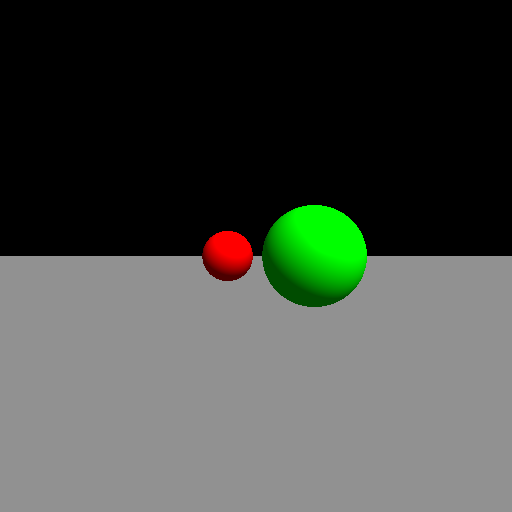

In [34]:
# Create camera (and image resolution)
nrows = 512
ncols = 512
# Focal distance
f = 250.0

myCamera = Camera(f, nrows, ncols)

##################
# simple scene 1
##################
object_list = []
# Object 1
Center = np.array((-90, 0, -800.0)).transpose()
Radius = 80.0
Color = np.array((255, 0, 0)).transpose()
object_list.append(Sphere(Center, Radius, Color))

# Object 2
Center = np.array((90, 0, -400.0)).transpose()
Radius = 80.0
Color = np.array((0, 255, 0)).transpose()
object_list.append(Sphere(Center, Radius, Color))

# Object 3 (the plane)
p1 = np.array((0.0, -500, 0.0)).transpose()
n = np.array((0.0, 1, 0.0)).transpose()
Color = np.array((150, 150, 150)).transpose()
object_list.append(Plane(p1, n, Color))

##################
# Create the scene (collection of objects - hardcoded for simplicity)
##################
theScene = Scene(myCamera, object_list)

image_matrix = theScene.construct_scene(nrows, ncols)


# Create an image from an array (display image and save file)
out_image = im.fromarray(np.uint8(image_matrix))
display(out_image)

out_image.save('raytraced_scene.png')

#Generate more complex Scene

## Variables

In [35]:
#@title Creating Objects In Scene

"""
class Material:
  def __init__(self, reflective = False, reflective_amount = 0, refract = False, refraction_index = 0, refract_amount = 0):
    self.reflective = reflective
    self.reflective_amount = reflective_amount
    self.refract = refract
    self.refraction_index = refraction_index
    self.refract_amount = refract_amount
"""

Allow_Reflection = True #@param {type:"boolean"}
Allow_Refraction = True #@param {type:"boolean"}
Allow_Gloss = True #@param {type:"boolean"}


objectList = []
# Object 1
Center = np.array((-90, 0, -800.0)).transpose()
Radius = 80.0
Color = np.array((170, 0, 0)).transpose()
material = Material(reflective = Allow_Reflection, reflective_amount = 0.5)
objectList.append(Sphere(Center, Radius, Color, material))

# Object 2
Center = np.array((90, 0, -500.0)).transpose()
Radius = 80.0
Color = np.array((0, 170, 0)).transpose()
material = Material(reflective = Allow_Reflection, reflective_amount = 0.3)
objectList.append(Sphere(Center, Radius, Color, material))

# Object 3 (triangle)
p1 = np.array((-300, -100, -100.0)).transpose()
p2 = np.array((0, -100, -1500)).transpose()
p3 = np.array((300, -100, -100)).transpose()
Color = np.array((100, 100, 100 )).transpose()
material = Material(reflective = Allow_Reflection, reflective_amount = 0.7)
objectList.append(Triangle(p1, p2, p3, Color, material))

# Object 4 (square)
p1 = np.array((-800, -100, -1000)).transpose()
p2 = np.array((800, -100, -1000)).transpose()
p3 = np.array((-800, 500, -1000)).transpose()
p4 = np.array((800, 500, -1000)).transpose()
Color = np.array((150, 100, 100 )).transpose()
material = Material(reflective = Allow_Reflection, reflective_amount = 1)
objectList.append(Square(p1, p2, p3, p4, Color, material))

# Object 5
Center = np.array((15, -50, -200.0)).transpose()
Radius = 35.0
Color = np.array((10, 10, 10)).transpose()
material = Material(reflective = Allow_Reflection,
                    reflective_amount = 0.0,
                    refract = Allow_Refraction,
                    refraction_index = 1.8,
                    refract_amount = 0.7)
objectList.append(Sphere(Center, Radius, Color, material))

# Object 6
Center = np.array((-50, -70, -150.0)).transpose()
Radius = 30.0
Color = np.array((0, 0, 140)).transpose()
material = Material(reflective = Allow_Reflection,
                    reflective_amount = 0.6,
                    gloss = Allow_Gloss,
                    gloss_amount = 0.1)
objectList.append(Sphere(Center, Radius, Color, material))

In [36]:
#@title Camera and Lighting Variables
#@markdown Set Pixel (Resolution) of Camera
xpix = 512 #@param {type:"integer"}
ypix = 512 #@param {type:"integer"}
#@markdown Focal distance
focal = 250.0 #@param {type:"number"}

#@markdown Set Camera postion
camera_xpos = 0 #@param {type:"number"}
camera_ypos = 0 #@param {type:"number"}
camera_zpos = 0 #@param {type:"number"}
eye = np.array((camera_xpos, camera_ypos, camera_zpos)).transpose()

#@markdown Set light postion
light_x = 7 #@param {type:"number"}
light_y = 10 #@param {type:"number"}
light_z = 5 #@param {type:"number"}
light_source = []
for x,z in [[-1, -1], [0,-1], [1,-1], [-1,0], [0,0], [1,0], [-1, 1], [0, 1], [1, 1]]:
    light_source.append(np.array((light_x + x, light_y, light_z + z)))
myCamera = Camera(focal, xpix, ypix)

In [37]:
#@title Environment Variables
Ambient = 0.3 #@param {type:"slider", min:0, max:1, step:0.005}
Diffuse = 0.55 #@param {type:"slider", min:0, max:1, step:0.005}
Specular = 0.75 #@param {type:"slider", min:0, max:1, step:0.005}
Light_Bounces = 1 # @param {"type":"slider","min":0,"max":10,"step":2}

#@markdown Set background color
Background_R = 38 #@param {type:"slider", min:0, max:255, step:1}
Background_G = 120 #@param {type:"slider", min:0, max:255, step:1}
Background_B = 120 # @param {"type":"slider","min":0,"max":255,"step":1}
Background_Color = np.array((Background_R, Background_G, Background_B)).transpose()

#@markdown Allow shadows
Allow_Shadow = True #@param {type:"boolean"}

scene_environment = Environment(Ambient, Diffuse, Specular, Light_Bounces, Background_Color, Allow_Shadow)

In [38]:

#@title Testing single raycast
TestScene = Scene(myCamera, objectList, light_source, scene_environment)
Img_matrix = TestScene.construct_scene(1, 1)
i = int(xpix/2)
j = int(ypix/2)
ray = myCamera.constructRayThroughPixel(i, j)

# Intersect the ray with the scene (all objects in the scene)
hit = TestScene.find_intersection(ray)

total_color = TestScene.get_color(hit, ray, TestScene.Environment.light_bounces)
print(total_color)

[114.27230304 170.84820203 170.84820203]


## Rendering Scene

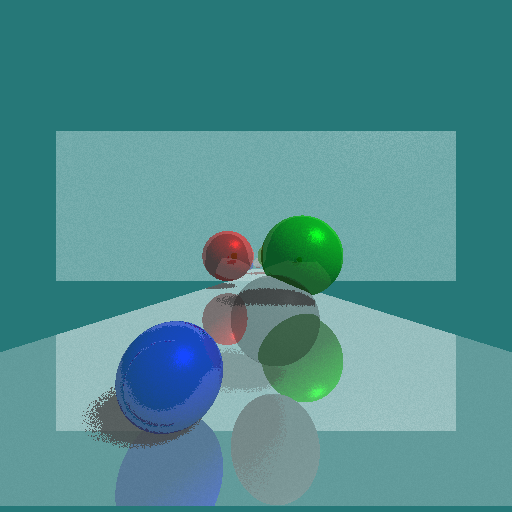

In [39]:
#@title Create the scene

MyScene = Scene(myCamera, objectList, light_source, scene_environment)
Img_matrix = MyScene.construct_scene(xpix, ypix)


# Create an image from an array (display image and save file)
img = im.fromarray(np.uint8(Img_matrix))
display(img)
img.save('raytraced_scene2.png')

In [45]:
#@title Set Different Camera Angles

# camera_2
position = np.array([200, 200, 0])
direction = np.array([-0.2, -0.2, -0.6])
Camera2 = Camera(focal, xpix, ypix, position, direction)

# camera_3
position = np.array([-100, 500, 0])
direction = np.array([0.1, -0.3, -0.6])
Camera3 = Camera(focal, xpix, ypix, position, direction)

# camera_4
position = np.array([-500, 0, -100])
direction = np.array([0.4, 0, -0.6])
Camera4 = Camera(focal, xpix, ypix, position, direction)

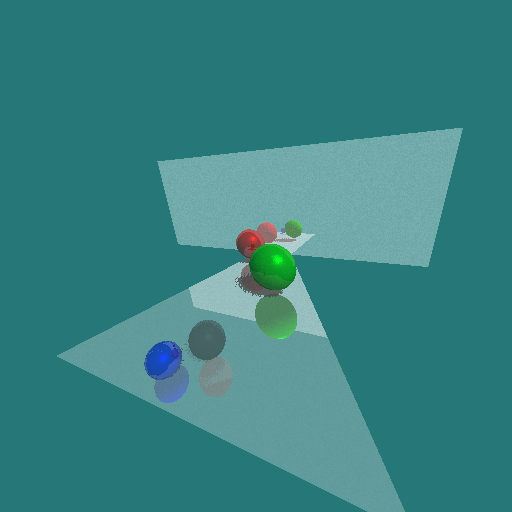

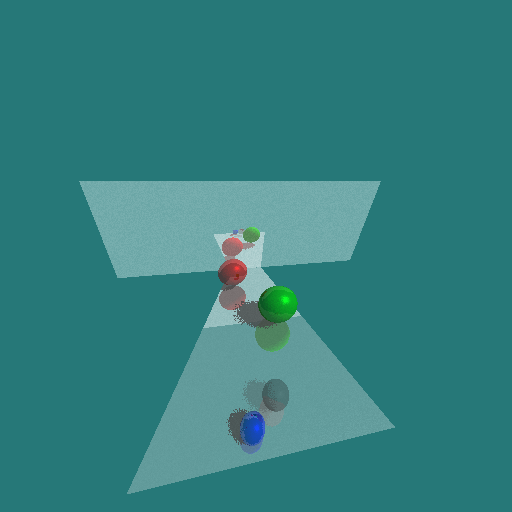

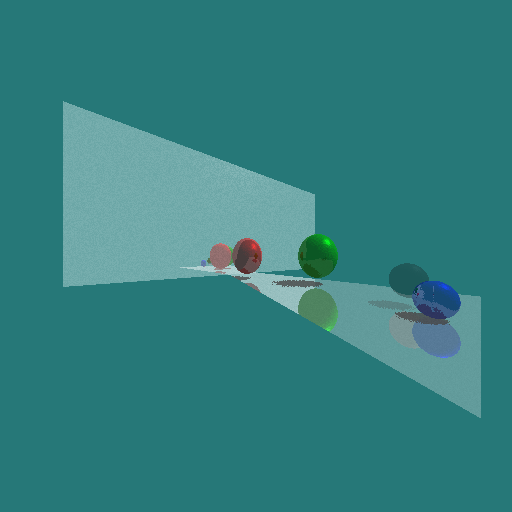

In [46]:
#@title Reder Multiple Pamera

MyScene2 = Scene(Camera2, objectList, light_source, scene_environment)
Img_matrix2 = MyScene2.construct_scene(xpix, ypix)
# Create an image from an array (display image and save file)
img2 = im.fromarray(np.uint8(Img_matrix2))
display(img2)
img.save('raytraced_scene2_cam2.png')

MyScene3 = Scene(Camera3, objectList, light_source, scene_environment)
Img_matrix3 = MyScene3.construct_scene(xpix, ypix)
# Create an image from an array (display image and save file)
img3 = im.fromarray(np.uint8(Img_matrix3))
display(img3)
img3.save('raytraced_scene2_cam3.png')

MyScene4 = Scene(Camera4, objectList, light_source, scene_environment)
Img_matrix4 = MyScene4.construct_scene(xpix, ypix)
# Create an image from an array (display image and save file)
img4 = im.fromarray(np.uint8(Img_matrix4))
display(img4)
img4.save('raytraced_scene2_cam4.png')